## Set root

In [47]:
import pyrootutils
from pathlib import Path
import os

root = pyrootutils.setup_root(Path.cwd(), indicator=".project-root", pythonpath=True)
root_cifar10 = root / "cifar10"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of mahalanobis failed: Traceback (most recent call last):
  File "c:\Julia_Projects\safetycage-tutorials\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "c:\Julia_Projects\safetycage-tutorials\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "C:\Users\juliaq\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\importlib\__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "c:\Julia_Projects\safetycage-tutorials\cifar10\mahalanobis.py", line 13, in <module>
    from safetycage import SafetyCage
ImportError: cannot import name 'SafetyCage' from 'safetycage' (

## Load data module and predictions
Then the predictions are loaded into the data module. These will be packaged together with the other data samples.

Data loaded from C:\Julia_Projects\safetycage-tutorials\cifar10\metadata\data\cifar10.npz.


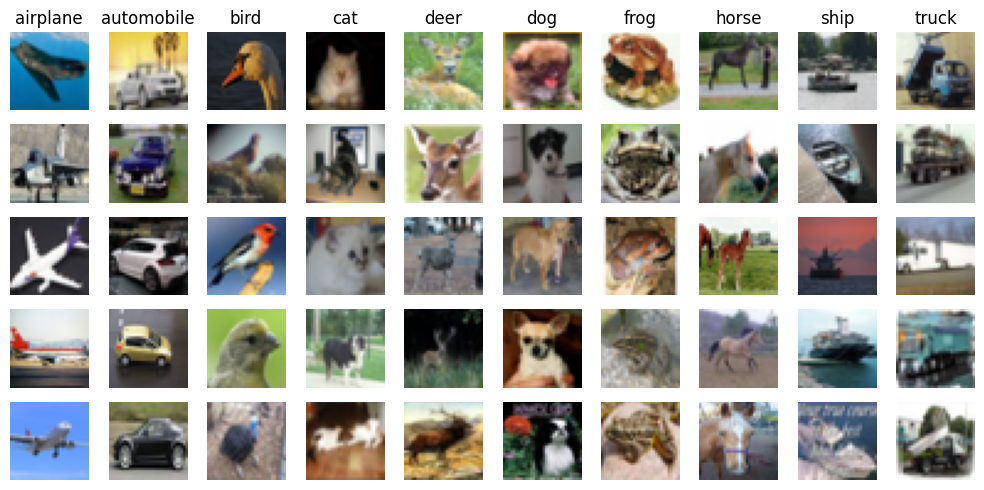

In [48]:
import numpy as np
from cifar10.modules.keras_cifar10_datamodule import CIFAR10DataModule

data_module = CIFAR10DataModule(
    data_dir=root_cifar10 / "metadata/data"
).from_joblib()

data_module.plot_samples()

# Load prediction model
You can choose between an MLP and a CNN.

In [49]:
from keras.models import load_model

model = load_model(root_cifar10 / "metadata/model")

model.summary()

Model: "cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_1 (Reshape)         (None, 32, 32, 3)         0         
                                                                 
 conv2d_3 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 4, 4, 64)          36928   

## Instantiate the model module.
The model module acts as a translator between the model and safetycage, translating the syntax of the model to something standardize that the safetycage can use, for all models.

In [50]:
from cifar10.modules.keras_modelmodule import KerasModelModule

model_module = KerasModelModule(
    model=model, selected_layers=["dense_3"], use_onehot_encoder=True
)

In [51]:
inputs_train, labels_train = data_module.data_train

predictions_train = model_module._get_predictions(inputs_train)

1250/1250 [==============================] - 6s 5ms/step


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(labels_train, predictions_train)
precision = precision_score(labels_train, predictions_train, average="weighted")
recall = recall_score(labels_train, predictions_train, average="weighted")

print("Performance on training data:")
print(f"Accuracy: {accuracy * 100:.4f} %")
print(f"Precision: {precision * 100:.4f} %")
print(f"Recall: {recall * 100:.4f} %")

Performance on training data:
Accuracy: 77.4925 %
Precision: 79.5396 %
Recall: 77.4925 %


## Instantiate a safetycage

In [53]:
from mahalanobis import Mahalanobis

safetycage = Mahalanobis(model_module, data_module, use_preactivations = True, empirical = False,
                         cauchy_weights_per_layer = [], test_type_between_layers = "cauchy", test_type_within_layer = "chi2", alpha = "null")

## Train the safetycage

In [54]:
# Train the safety cage on training data
# safetycage.train_cage(x=inputs_train, y=labels_train, y_pred=predictions_train)
safetycage.train_cage()

1250/1250 [==============================] - 6s 5ms/step


## Safetycage predicts on validation data
Safetycage predicts whether samples have been misclassified by classifier. The type of statistic will vary depending on the safetycage method, but will say something about how likely it is a given sample has been misclassified.

In [55]:
inputs_val, labels_val = data_module.data_val

predictions_val = model_module._get_predictions(inputs_val)
incorrect_predictions_val = ~(
    np.argmax(predictions_val, axis=1) == np.argmax(labels_val, axis=1)
)

max_probs_val = safetycage.predict(
    x=inputs_val,
    y=predictions_val,
)

313/313 [==============================] - 2s 4ms/step


## Find threshold that maximizes a performance metric
Use the statistics from the validation data produced by the safetycage, to find a theshold that will maximize a metric, when compared to the ground truth (correct or incorrect classification)

In [56]:
from safetycage.utils.evaluate import find_best_threshold, MCC, accuracy

metric = accuracy

# Find optimal alpha for specified max metric based on the validation data
optimisation_result = find_best_threshold(
    y_probs=max_probs_val,
    y_true=incorrect_predictions_val,
    metric_fn=metric,
    greater_is_better=True,
)

threshold_val = optimisation_result["alpha_opt"]
metric_val = optimisation_result["metric_max"]

print("\nOptimal threshold and performance metric based on validation data:")
print(f"Threshold = {threshold_val:.4f}")
print(f"{metric.__name__} = {metric_val:.4f}")

safetycage.alpha = threshold_val
safetycage.threshold_metric_val = metric_val

threshold_flag_result = safetycage.find_best_threshold_flag(
    y_probs=max_probs_val,
    y_true=incorrect_predictions_val,
    metric_fn=metric
)

print("\nOptimal threshold and performance metric using safetycage.flag() based on validation data:")
print(f"Flag Threshold = {threshold_flag_result['alpha_opt']:.4f}")
print(f"{metric.__name__} = {threshold_flag_result['metric_max']:.4f}")

print(f"\nThresholds Difference = {optimisation_result['alpha_opt'] - threshold_flag_result['alpha_opt']:.4f}")
print(f"Metric Difference = {optimisation_result['metric_max'] - threshold_flag_result['metric_max']:.4f}")


Optimal threshold and performance metric based on validation data:
Threshold = 0.0001
accuracy = 0.6661

Optimal threshold and performance metric using safetycage.flag() based on validation data:
Flag Threshold = 0.0000
accuracy = 0.6654

Thresholds Difference = 0.0001
Metric Difference = 0.0007


## Test with optimal threshold, the performance on the test data partition.
Finally we test the safetycage with the inferred threshold parameter, on a hold out test data set. The flags are the predicitons made by the safetycage.

In [57]:
inputs_test, labels_test = data_module.data_test

prediction_test = model_module._get_predictions(inputs_test)
incorrect_prediction_test = ~(
    np.argmax(prediction_test, axis=1) == np.argmax(labels_test, axis=1)
)

max_probs_test = safetycage.predict(
    x=inputs_test,
    y=prediction_test,
)

flags_test = safetycage.flag(max_probs_test)

313/313 [==============================] - 1s 4ms/step


# Calculate metrics of the predictions on the test data set.
Compute a set of metrics that will inform us of the safetycages abillity to flag misclassification made by a certain model on a certain dataset.

In [58]:
import json

from safetycage.utils.evaluate import (
    calculate_confusion_rates,
    calculate_metrics,
    calculate_auroc,
)

# Calculate confusion rates and metrics based on test data
confusion_rates_test = calculate_confusion_rates(
    y=incorrect_prediction_test,
    y_pred=flags_test,
)

# Calculate AUROC based on test data
auroc_test = calculate_auroc(
    safetycage=safetycage,
    y_true=incorrect_prediction_test,
    y_scores=max_probs_test,  # Assuming the first column contains the scores
)

# Calculate metrics based on test data
metrics_test = calculate_metrics(y=incorrect_prediction_test, y_pred=flags_test)

# Add confusion rates and AUROC to metrics dictionary
metrics_test.update(confusion_rates_test)
metrics_test.update({"AUROC": auroc_test})

os.makedirs("./results", exist_ok=True)
with open("./results/metrics_test.json", "w") as f:
    json.dump(metrics_test, f, indent=4)

for name, value in metrics_test.items():
    print(f"{name}: {value:.4f}")

Precision: 0.4261
Recall: 0.0150
Specificity: 0.9902
NPV: 0.6735
MCC: 0.0226
Accuracy: 0.6707
F1-score: 0.0289
TP: 49.0000
TN: 6658.0000
FP: 66.0000
FN: 3227.0000
AUROC: 0.5745


## Plots
Further we plot a number of figures showing further the performance of safetycage. These plots are the 
1. Confusion matrix, 
2. Threshold-metric curve (how the  metric varies with the threshold)
3. Reciever-operator curve.

In [59]:
from safetycage.utils.evaluate import calculate_roc_curve

from safetycage.utils.plot_functions import (
    plot_alpha_metric_curve,
    plot_confusion_matrix,
    plot_roc_curve,
)

best_metric_dict = find_best_threshold(
    y_probs=max_probs_test,
    y_true=incorrect_prediction_test,
    metric_fn=metric,
    greater_is_better=True,
)

plots_folder = "./results/plots"

# plots
plot_alpha_metric_curve(
    **best_metric_dict,
    thresholds=optimisation_result["alphas"],
    scores=optimisation_result["metric_values"],
    output_path=plots_folder,
    alpha_val=safetycage.alpha,
    metric_val=safetycage.threshold_metric_val,
    val_label_offset=(0.0, 0.10) # the validation label tends to cover the data
)

plot_confusion_matrix(
    y_true=incorrect_prediction_test,
    y_pred=flags_test,
    normalize=None,
    output_path=plots_folder,
)

roc = calculate_roc_curve(
    safetycage=safetycage,
    y_true=incorrect_prediction_test,
    statistics=max_probs_test,
    num_thresholds=1e4,
)

plot_roc_curve(
    **roc,
    output_path=plots_folder
)

In [60]:
safetycage.save_cage("./saved_cage")

In [61]:
safetycage.alpha = None
safetycage.layer_params = None

safetycage.load_cage("./saved_cage")

print(safetycage.alpha)
print(safetycage.layer_params)

0.00013596051186332746
{'dense_3': {0: {}, 1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}, 7: {}, 8: {}, 9: {}, 'airplane': {'mean': array([ 5.2408495 , -3.4219089 , -0.02599822, -2.0607157 , -1.0417434 ,
       -4.0788174 , -4.9147487 , -2.938067  , -1.1139187 , -2.698702  ],
      dtype=float32), 'variance': array([[ 5.71987429, -0.5269759 ,  1.53162577, -1.43455647,  1.12192283,
        -3.40175425, -1.69629122, -2.1476738 ,  0.88273246, -1.16710803],
       [-0.5269759 ,  8.3575737 , -3.58024804, -2.52998469, -2.3331062 ,
        -2.5700827 , -1.82374491,  0.44545506,  2.44421812,  5.61562328],
       [ 1.53162577, -3.58024804,  6.13640753,  0.71800127,  1.69999068,
        -0.09139434,  1.95500077, -1.67138773, -0.55323457, -3.89861863],
       [-1.43455647, -2.52998469,  0.71800127,  3.36864241, -0.02058082,
         3.32028848,  1.73869637, -0.46436734, -1.78798093, -1.54294255],
       [ 1.12192283, -2.3331062 ,  1.69999068, -0.02058082,  5.15979659,
        -0.74898276, -1.11135055,